In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import seaborn as sns
sns.set_theme()

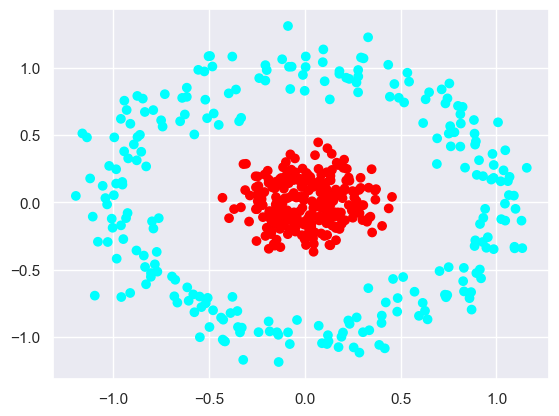

In [2]:
X, y=make_circles(n_samples=500, noise=0.1, random_state=42, factor=0.2)
y=2*y-1
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['cyan', 'red']));

In [3]:
def plot_decision_boundary(model, X, y, ax=None, alpha=1, plot_points=True):
    if ax is None:
        ax=plt.axes()
    points_x=np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    points_y=np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    mesh=np.meshgrid(points_x, points_y)
    df=pd.DataFrame(np.column_stack((mesh[0].flatten(), mesh[1].flatten())))
    
    predictions=model.predict(df)
    ax.scatter(df[0], df[1], s=5, marker='.', c=predictions+2, 
               cmap=colors.ListedColormap(['blue', 'yellow']), alpha=alpha)
    if plot_points:
        ax.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['cyan', 'orange']), edgecolors='k')

    return ax
    


# Task 1

In [216]:
class AdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, learning_rate=0.5, n_estimators=10, random_state=0):
        self.estimator=estimator # the learner that will be used
        self.learning_rate=learning_rate # the learning rate that will be used
        self.n_estimators=n_estimators # the number of max estimators to add in the ensemble
        self.actual_iterations=0 # actual iterations took to fit the model
        self.estimators=[]  # the list of trained estimators
        self.weights=[] # alphas weight of each estimator
        self.random_state=random_state
        self._is_fitted=False

    def calc_error(self, y_true, y_pred, distribution):
        return ((y_true != y_pred)*distribution).sum()
    
    def calc_weight(self, error):
        if error==0:
            return 10
        elif error>=0.5:
            # raise ValueError('A weak learner was not encountered.\n Provide a weak learner')
            return 0.01
        else:
            return self.learning_rate * np.log2((1-error)/error)
    
    def updated_distribution(self, y_true, y_pred, distribution, new_alpha):
        un_normalised=np.exp((-new_alpha)*y_true*y_pred)*distribution
        return un_normalised/un_normalised.sum()


    def fit(self, X, y):
        n=X.shape[0]
        self.estimators=[]
        self.weights=[]
        self.actual_iterations=0
        distribution=np.array([1/n]*n)

        for i in range(self.n_estimators):
            new_estimator=clone(self.estimator)
            new_estimator.fit(X, y, sample_weight=distribution)
            predictions=new_estimator.predict(X)
            error=self.calc_error(y, predictions, distribution)
            new_alpha=self.calc_weight(error)

            self.estimators.append(new_estimator)
            self.weights.append(new_alpha)
            self.actual_iterations+=1
            
            if error==0:
                break
            
            distribution=self.updated_distribution(y, predictions, distribution, new_alpha)

        self._is_fitted=True
        return self
    
    def predict(self, X):
        ensemble_predictions=np.zeros(X.shape[0])
        for i in range(self.actual_iterations):
            ensemble_predictions+=self.weights[i]*self.estimators[i].predict(X)
        
        positive=(ensemble_predictions>=0)
        ensemble_predictions[positive]=1
        ensemble_predictions[~positive]=-1
        return ensemble_predictions
    
    def plot_decision_boundary_pair(self, X, y, alpha=1):
        fig, axes=plt.subplots(ncols=2)
        for i in range(self.actual_iterations):
            points=False
            if i==self.actual_iterations-1:
                points=True
            plot_decision_boundary(self.estimators[i], X, y, ax=axes[0],
                                   alpha=alpha, plot_points=points)
        plot_decision_boundary(self, X, y, ax=axes[1], alpha=0.4)
        axes[0].set_xlabel('$X_1$')
        axes[0].set_ylabel('$X_2$')
        axes[1].set_xlabel('$X_1$')
        axes[1].set_ylabel('$X_2$')
        return fig, axes
            

    def __sklearn_is_fitted__(self):
        return self._is_fitted

In [8]:
dt=DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1)

In [78]:
clsf=AdaBoost(dt, n_estimators=1000)
clsf.fit(X_train, y_train)

AdaBoost(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=1000)

In [79]:
clsf.actual_iterations

1000

In [80]:
predictions=clsf.predict(X_train)
(predictions==y_train).mean()

np.float64(1.0)

In [81]:
predictions=clsf.predict(X_test)
(predictions==y_test).mean()

np.float64(1.0)

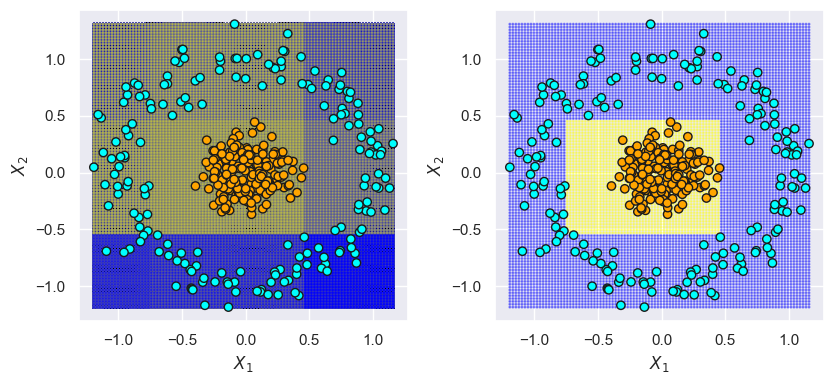

In [82]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.4)
fig.set_size_inches(8.5, 4)
plt.tight_layout()

# Task 2

In [278]:
def model_report(model):
    print('Train Performance:')
    predictions=model.predict(X_train)
    score=np.mean((predictions==y_train))*100
    print('\tAccuracy Score: %.3f'%score)
    
    print('Test Performance:')
    predictions=model.predict(X_test)
    score=np.mean((predictions==y_test))*100
    print('\tAccuracy Score: %.3f'%score)

### Decision Stump

In [275]:
gscv=GridSearchCV(estimator=AdaBoost(estimator=DecisionTreeClassifier(max_depth=1)), 
                  param_grid={'learning_rate': [0.4, 0.5, 0.6],
                                'n_estimators': [20, 50, 100, 200, 250]},
                  cv=5, refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoost(estimator=DecisionTreeClassifier(max_depth=1)),
             n_jobs=-1,
             param_grid={'learning_rate': [0.4, 0.5, 0.6],
                         'n_estimators': [20, 50, 100, 200, 250]},
             refit=False)

In [276]:
print('Best Params:' + repr(gscv.best_params_))
print('Best Score: %.3f'%gscv.best_score_)

Best Params:{'learning_rate': 0.4, 'n_estimators': 20}
Best Score: 0.989


In [277]:
clsf=AdaBoost(estimator=DecisionTreeClassifier(max_depth=1), **gscv.best_params_)
clsf.fit(X_train, y_train)

AdaBoost(estimator=DecisionTreeClassifier(max_depth=1), learning_rate=0.4,
         n_estimators=20)

In [279]:
model_report(clsf)

Train Performance:
	Accuracy Score: 100.000
Test Performance:
	Accuracy Score: 99.200


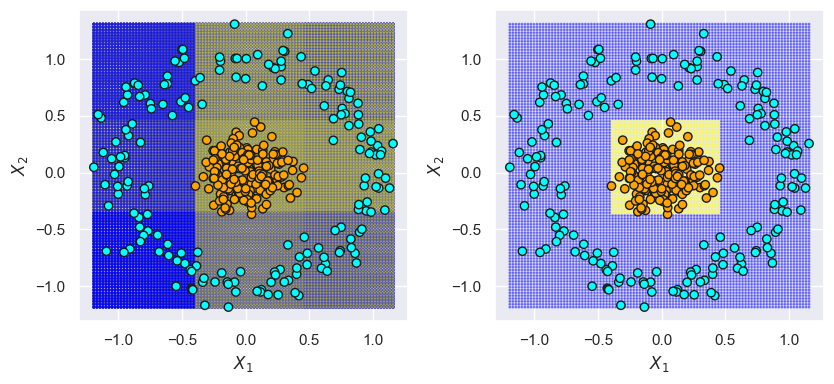

In [281]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.4)
fig.set_size_inches(8.5, 4)
plt.tight_layout()

### Descision Tree with `max_depth=3`

In [282]:
gscv=GridSearchCV(estimator=AdaBoost(estimator=DecisionTreeClassifier(max_depth=3)), 
                  param_grid={'learning_rate': [0.4, 0.5, 0.6],
                                'n_estimators': [20, 50, 100, 200, 250]},
                  cv=5, refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoost(estimator=DecisionTreeClassifier(max_depth=3)),
             n_jobs=-1,
             param_grid={'learning_rate': [0.4, 0.5, 0.6],
                         'n_estimators': [20, 50, 100, 200, 250]},
             refit=False)

In [283]:
print('Best Params:' + repr(gscv.best_params_))
print('Best Score: %.3f'%gscv.best_score_)

Best Params:{'learning_rate': 0.4, 'n_estimators': 200}
Best Score: 0.995


In [284]:
clsf=AdaBoost(estimator=DecisionTreeClassifier(max_depth=3), **gscv.best_params_)
clsf.fit(X_train, y_train)

AdaBoost(estimator=DecisionTreeClassifier(max_depth=3), learning_rate=0.4,
         n_estimators=200)

In [285]:
model_report(clsf)

Train Performance:
	Accuracy Score: 100.000
Test Performance:
	Accuracy Score: 100.000


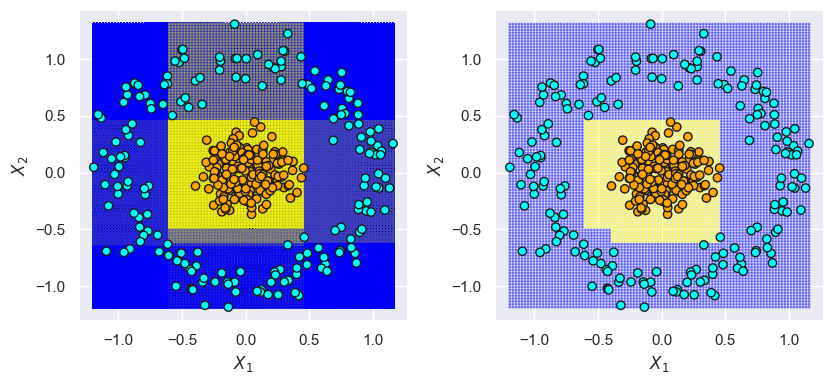

In [286]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.4)
fig.set_size_inches(8.5, 4)
plt.tight_layout()

### Linear SVM

In [287]:
gscv=GridSearchCV(estimator=AdaBoost(estimator=LinearSVC()), 
                  param_grid={'learning_rate': [0.4, 0.5, 0.6],
                                'n_estimators': [20, 50, 100, 200, 250]},
                  cv=5, refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoost(estimator=LinearSVC()), n_jobs=-1,
             param_grid={'learning_rate': [0.4, 0.5, 0.6],
                         'n_estimators': [20, 50, 100, 200, 250]},
             refit=False)

In [288]:
print('Best Params:' + repr(gscv.best_params_))
print('Best Score: %.3f'%gscv.best_score_)

Best Params:{'learning_rate': 0.4, 'n_estimators': 250}
Best Score: 0.949


In [293]:
clsf=AdaBoost(estimator=LinearSVC(), **gscv.best_params_)
clsf.fit(X_train, y_train)

AdaBoost(estimator=LinearSVC(), learning_rate=0.4, n_estimators=250)

In [294]:
model_report(clsf)

Train Performance:
	Accuracy Score: 100.000
Test Performance:
	Accuracy Score: 99.200


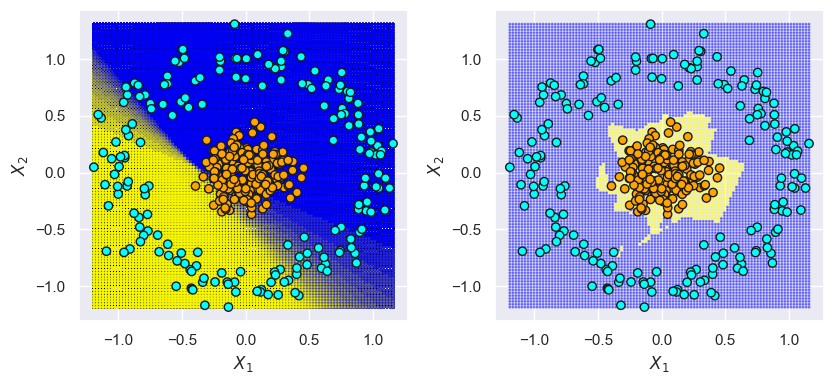

In [295]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.1)
fig.set_size_inches(8.5, 4)
plt.tight_layout()

### Logistic Regression

In [296]:
gscv=GridSearchCV(estimator=AdaBoost(estimator=LogisticRegression()), 
                  param_grid={'learning_rate': [0.4, 0.5, 0.6],
                                'n_estimators': [20, 50, 100, 200, 250]},
                  cv=5, refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoost(estimator=LogisticRegression()),
             n_jobs=-1,
             param_grid={'learning_rate': [0.4, 0.5, 0.6],
                         'n_estimators': [20, 50, 100, 200, 250]},
             refit=False)

In [297]:
print('Best Params:' + repr(gscv.best_params_))
print('Best Score: %.3f'%gscv.best_score_)

Best Params:{'learning_rate': 0.4, 'n_estimators': 250}
Best Score: 1.000


In [298]:
clsf=AdaBoost(estimator=LogisticRegression(), **gscv.best_params_)
clsf.fit(X_train, y_train)

AdaBoost(estimator=LogisticRegression(), learning_rate=0.4, n_estimators=250)

In [299]:
model_report(clsf)

Train Performance:
	Accuracy Score: 100.000
Test Performance:
	Accuracy Score: 100.000


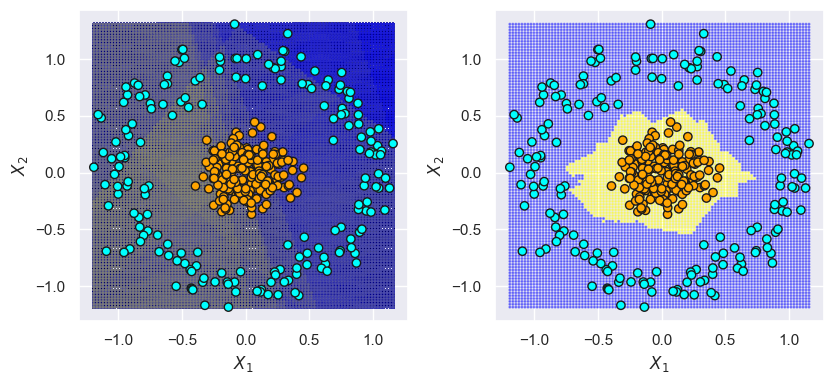

In [301]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.1)
fig.set_size_inches(8.5, 4)
plt.tight_layout()